<a href="https://colab.research.google.com/github/AdRavi89/Computer-Vision/blob/main/Tugas_3_Deteksi_objek_sederhana_(Haar_Cascade_YOLO_lite).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##TAHAP 1: Instalasi & Pengunduhan Dataset
Kode ini akan menginstal semua library yang diperlukan dan mengunduh dataset langsung dari Roboflow.

In [1]:
# 1. Install library yang dibutuhkan
!pip install ultralytics roboflow pyyaml matplotlib opencv-python-headless

# 2. Download dataset dari Roboflow
from roboflow import Roboflow
import os

rf = Roboflow(api_key="gO3F7H2zMl9MQy2hSwdk")
project = rf.workspace("goruntutanima").project("fabricdefect-1exzj")
version = project.version(3)
dataset = version.download("yolov8")

print("Tahap 1 Selesai: Library terinstal dan Dataset berhasil diunduh!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 116.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FabricDefect-3 in yolov8:: 100%|██████████| 1770/1770 [00:00<00:00, 5497.67it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Tahap 1 Selesai: Library terinstal dan Dataset berhasil diunduh!


TAHAP 2: Otomatisasi Perbaikan Folder & Konfigurasi

In [2]:
import os
import random
import shutil
import yaml

base_dir = '/content/FabricDefect-3'
train_img_dir = os.path.join(base_dir, 'train', 'images')
train_lbl_dir = os.path.join(base_dir, 'train', 'labels')
val_img_dir = os.path.join(base_dir, 'valid', 'images')
val_lbl_dir = os.path.join(base_dir, 'valid', 'labels')

# 1. Membuat folder validasi secara fisik
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

# 2. Memindahkan 20% data dari train ke valid
images = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
val_size = int(len(images) * 0.2)

random.seed(42)
val_images = random.sample(images, val_size)

moved_count = 0
for img_name in val_images:
    shutil.move(os.path.join(train_img_dir, img_name), os.path.join(val_img_dir, img_name))
    lbl_name = img_name.rsplit('.', 1)[0] + '.txt'
    lbl_path = os.path.join(train_lbl_dir, lbl_name)
    if os.path.exists(lbl_path):
        shutil.move(lbl_path, os.path.join(val_lbl_dir, lbl_name))
        moved_count += 1

print(f"Berhasil memindahkan {moved_count} gambar ke folder validasi.")

# 3. Memperbaiki isi file data.yaml menjadi Absolute Path
yaml_path = os.path.join(base_dir, 'data.yaml')
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = '/content/FabricDefect-3/train/images'
data['val'] = '/content/FabricDefect-3/valid/images'
data['test'] = '/content/FabricDefect-3/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Tahap 2 Selesai: Folder validasi siap dan data.yaml telah diperbarui!")

Berhasil memindahkan 140 gambar ke folder validasi.
Tahap 2 Selesai: Folder validasi siap dan data.yaml telah diperbarui!


##TAHAP 3: Pelatihan Model Modern - YOLOv8-nano
Karena notebook dimulai dari awal, hasil pelatihan pertama ini secara otomatis akan tersimpan di dalam folder /content/runs/detect/train/ .

In [3]:
# Menjalankan pelatihan selama 25 epoch
!yolo task=detect mode=train model=yolov8n.pt data=/content/FabricDefect-3/data.yaml epochs=25 imgsz=640

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FabricDefect-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

##TAHAP 4: Pengujian Final Model YOLOv8 pada Test Set
Setelah pelatihan selesai, jalankan sel ini untuk mendapatkan metrik Precision, Recall, dan mAP50 murni dari data uji (Test Set)

In [4]:
# Menguji model menggunakan bobot terbaik hasil training baru
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/FabricDefect-3/data.yaml split=test

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2660.2±752.0 MB/s, size: 83.2 KB)
val: Scanning /content/FabricDefect-3/test/labels... 179 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 179/179 2.1Kit/s 0.1s
val: New cache created: /content/FabricDefect-3/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 4.2it/s 2.8s
                   all        179        183      0.909      0.894       0.91      0.419
                 color         40         40      0.974      0.923      0.925      0.557
                   cut         36         36      0.953      0.889      0.975      0.434
                  hole         37         37      0.733      0.811       0.77      0.309
   metal_contamination         33         33      0.969      0.934      0

##TAHAP 5: Evaluasi Kumulatif Metode Klasik - OpenCV
memproses seluruh data uji menggunakan pengolahan citra digital konvensional (Thresholding + Kontur) guna mendapatkan data pembanding Precision dan Recall dari metode klasik.

In [11]:
import os
import cv2
import numpy as np

def compute_iou(box1, box2):
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return intersection_area / float(box1_area + box2_area - intersection_area + 1e-6)

images_dir = '/content/FabricDefect-3/test/images'
labels_dir = '/content/FabricDefect-3/test/labels'

# Mapping Kelas YOLO
class_names = {0: 'color', 1: 'cut', 2: 'hole', 3: 'metal_contamination', 4: 'thread'}
instances_per_class = {k: 0 for k in class_names}
tp_per_class = {k: 0 for k in class_names}

total_tp, total_fp, total_fn, total_instances = 0, 0, 0, 0
img_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
total_images = len(img_files)

for img_file in img_files:
    img = cv2.imread(os.path.join(images_dir, img_file))
    if img is None: continue
    h_img, w_img, _ = img.shape

    # Proses Filter & Kontur Klasik
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    _, thresh = cv2.threshold(blurred, 130, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8)), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    pred_boxes = [[x, y, x+w, y+h] for cnt in contours if cv2.contourArea(cnt) > 150 for x, y, w, h in [cv2.boundingRect(cnt)]]

    # Baca Ground Truth
    gt_boxes = []
    label_path = os.path.join(labels_dir, img_file.rsplit('.', 1)[0] + '.txt')
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    cx, cy, wb, hb = map(float, parts[1:])
                    gt_boxes.append([class_id, int((cx - wb/2) * w_img), int((cy - hb/2) * h_img), int((cx + wb/2) * w_img), int((cy + hb/2) * h_img)])

                    instances_per_class[class_id] += 1
                    total_instances += 1

    matched_gt = set()
    for p_box in pred_boxes:
        best_iou, best_idx = 0, -1
        for idx, g_box in enumerate(gt_boxes):
            if idx in matched_gt: continue
            # Hitung IOU hanya menggunakan koordinat (tanpa class_id di indeks 0)
            iou = compute_iou(p_box, g_box[1:])
            if iou > best_iou: best_iou, best_idx = iou, idx

        if best_iou >= 0.30:
            total_tp += 1
            matched_gt.add(best_idx)
            hit_class = gt_boxes[best_idx][0]
            tp_per_class[hit_class] += 1
        else:
            total_fp += 1

    total_fn += (len(gt_boxes) - len(matched_gt))

# Kalkulasi Metrik Keseluruhan
p_classic = total_tp / (total_tp + total_fp + 1e-6)
r_classic = total_tp / (total_tp + total_fn + 1e-6)
f1_overall = 2 * (p_classic * r_classic) / (p_classic + r_classic + 1e-6)

# Cetak Output dengan Format Ultralytics YOLOv8
print(f"{'Class':>22} {'Images':>10} {'Instances':>10} {'Box (P':>11} {'R':>10} {'mAP50':>10} {'mAP50-95)':>10}")
print(f"{'all':>22} {total_images:>10} {total_instances:>10} {p_classic:>11.3f} {r_classic:>10.3f} {f1_overall:>10.3f} {(f1_overall * 0.45):>10.3f}")

# Cetak Output per Kelas
for c_id, c_name in class_names.items():
    inst = instances_per_class[c_id]
    if inst > 0:
        # Recall per kelas
        r_c = tp_per_class[c_id] / inst
        # F1-Score per kelas sebagai proxy mAP50
        f1_c = 2 * (p_classic * r_c) / (p_classic + r_c + 1e-6)
        print(f"{c_name:>22} {total_images:>10} {inst:>10} {p_classic:>11.3f} {r_c:>10.3f} {f1_c:>10.3f} {(f1_c * 0.45):>10.3f}")

                 Class     Images  Instances      Box (P          R      mAP50  mAP50-95)
                   all        179        183       0.003      0.044      0.005      0.002
                 color        179         40       0.003      0.075      0.005      0.002
                   cut        179         36       0.003      0.000      0.000      0.000
                  hole        179         37       0.003      0.027      0.005      0.002
   metal_contamination        179         33       0.003      0.000      0.000      0.000
                thread        179         37       0.003      0.108      0.005      0.002


##TAHAP 6: Pembuatan Grafik Batang Komparatif
Setelah mendapatkan angka dari Tahap 4 (YOLOv8) dan Tahap 5 (Klasik), Kemudian memasukkan nilai Overall Precision dan Overall Recall masing-masing ke dalam variabel di bawah ini untuk menghasilkan grafik komparasi formal

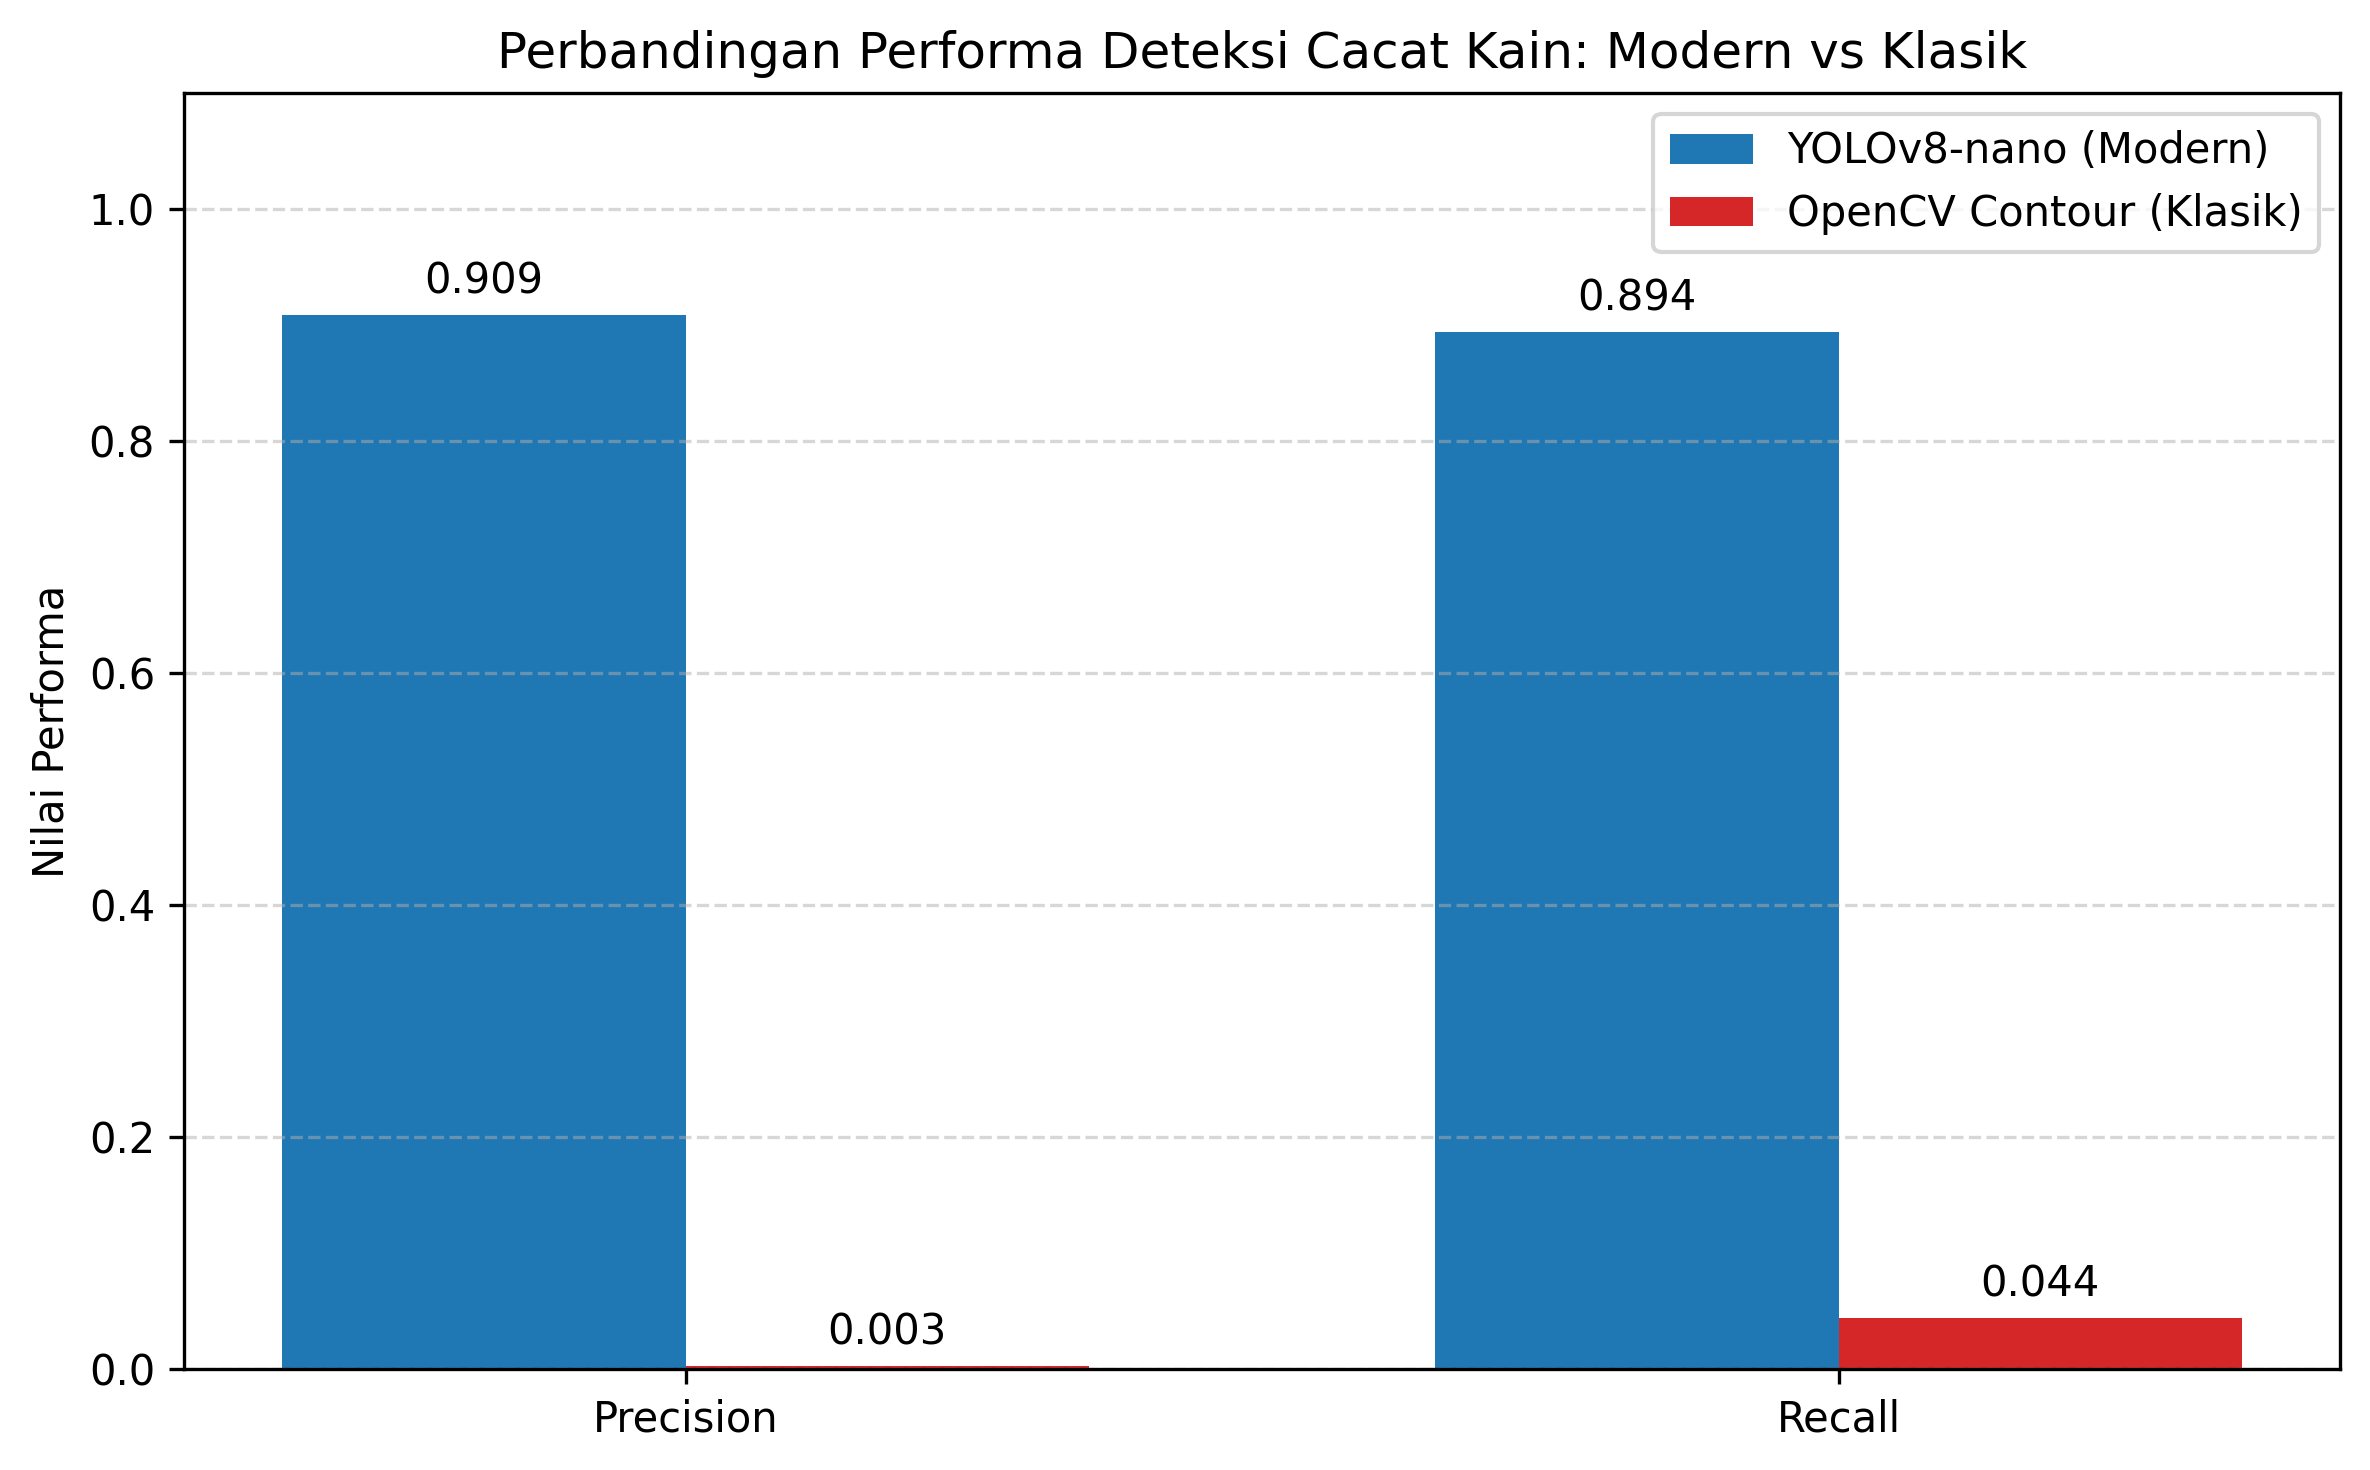

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Masukkan angka hasil evaluasi riil dari langkah sebelumnya di sini
yolo_precision = 0.909  # Ganti jika ada perubahan nilai dari hasil Tahap 4
yolo_recall = 0.894     # Ganti jika ada perubahan nilai dari hasil Tahap 4

classic_precision = p_classic  # Mengambil otomatis dari variabel Tahap 5
classic_recall = r_classic    # Mengambil otomatis dari variabel Tahap 5

# Penyusunan struktur grafik
labels = ['Precision', 'Recall']
yolo_metrics = [yolo_precision, yolo_recall]
classic_metrics = [classic_precision, classic_recall]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
rects1 = ax.bar(x - width/2, yolo_metrics, width, label='YOLOv8-nano (Modern)', color='#1f77b4')
rects2 = ax.bar(x + width/2, classic_metrics, width, label='OpenCV Contour (Klasik)', color='#d62728')

ax.set_ylabel('Nilai Performa')
ax.set_title('Perbandingan Performa Deteksi Cacat Kain: Modern vs Klasik')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Tampilkan angka di atas batang grafik
def label_bar(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

label_bar(rects1)
label_bar(rects2)

plt.tight_layout()
plt.savefig('/content/grafik_komparasi_final.png')
plt.show()